# WP4 Annex A, Level 5: petrophysical attachment, checked basis piece by basis piece

Level 5 is where each realization stops being geology and becomes something the forward models can consume. Lithology and ore are mapped to density, susceptibility and resistivity with era values and era uncertainty: basalt 2.80 to 3.00 g/cm3 and magnetic, cover units 2.4 to 2.6 and non-magnetic but conductive where saturated, and the ore blanket at analog grades close to invisible to gravity and magnetics. Shear velocity receives no era value, because none existed, so under the period prior the seismic channel is undefined, which the annex calls the historically correct state. Every value is marked [CHECK]. The level closes with *"Basis: the density contrasts the WMC interpreters themselves assumed when modeling the anomalies, with the era textbooks (Dobrin; Grant and West; Parasnis) as backup."* Two pieces, taken one at a time:

- **Part A: the contrasts the WMC interpreters assumed.** WMC's own sample measurements and model sheets are NOT FOUND (`wmc_assumed_contrasts/NOT_FOUND.md`): that work pre-dates the licence, so it sits in WMC's files, now BHP's, the same gap as Haynes's memoranda. What survives is Rutter and Esdale (1985), by the two WMC geophysicists themselves, and two pre-t0 measurement sets from SADME: Risely (1968) on the Roopena outcrops WMC later sampled, and Milton et al. (1966) at Mount Gunson.
- **Part B: the era textbooks.** Dobrin (1960, 2nd ed.), Grant and West (1965) and Parasnis (1973, Mining Geophysics 2nd ed.), all printed before t0, scanned page by page and transcribed into one table with the printed page and table number behind every value.

Each part ends with a verdict on its piece; Part C lays the Annex A Level 5 rows against what the folder can now cite. Only files in `wp4_prior_state/annexA_levels/level5_petrophysical_attachment/` are read. The information-state rule is one cutoff, t0 = 2 May 1975 (the EL 190 grant); the AMDEL core densities of October 1975, the December 1975 survey plans and Rutter and Esdale are all later, and are drawn in a separate colour throughout. Figures are drawn at final printed width and saved at 300 dpi to `03_results/wp4_prior/figures/` as `wp4_L5_*.png`.


In [1]:
# --- journal figure style ---------------------------------------------------
# Every text element has an explicit size; figures are drawn at final printed
# width so the point sizes below are the sizes that reach the page.
import matplotlib.pyplot as plt

FS_TICK, FS_LABEL, FS_LEGEND, FS_ANNOT, FS_PANEL = 8, 9, 8, 7, 9
COL1, COL15, COL2 = 3.5, 5.5, 7.2      # single / 1.5 / double column width (in)

plt.rcParams.update({
    # typeface
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": FS_TICK,
    # text elements
    "axes.labelsize": FS_LABEL,
    "axes.titlesize": FS_PANEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "legend.title_fontsize": FS_LEGEND,
    "figure.titlesize": FS_LABEL,
    # axes furniture: thin frame, ticks inward on all four sides, minor ticks
    "axes.linewidth": 0.6,
    "axes.grid": False,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4, "ytick.minor.width": 0.4,
    "xtick.major.size": 3.0, "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8, "ytick.minor.size": 1.8,
    # marks
    "lines.linewidth": 1.0,
    "lines.markersize": 3.0,
    "legend.frameon": False,
    "legend.handlelength": 1.6,
    "legend.borderaxespad": 0.4,
    # output
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

def panel_labels(axes, labels=("(a)", "(b)")):
    """Bold (a)/(b) above the top-left corner of each axes."""
    for ax, lab in zip(axes, labels):
        ax.set_title(lab, loc="left", fontsize=FS_PANEL, fontweight="bold")

# --- batlow: Crameri's scientific colour map (Crameri et al. 2020, Nat. Commun.)
# 32 anchor points interpolated to 256 steps; reproduces the published map to
# within 1.4/255 per channel. Embedded so the notebook needs no extra package.
from matplotlib.colors import LinearSegmentedColormap
_BATLOW = [
    (0.0052, 0.0982, 0.3498), (0.0321, 0.1468, 0.3582), (0.0494, 0.1911, 0.3658), (0.0592, 0.2298, 0.3723),
    (0.0679, 0.2671, 0.3782), (0.0771, 0.2970, 0.3824), (0.0903, 0.3257, 0.3849), (0.1097, 0.3531, 0.3842),
    (0.1413, 0.3812, 0.3771), (0.1778, 0.4030, 0.3638), (0.2201, 0.4219, 0.3443), (0.2662, 0.4386, 0.3201),
    (0.3208, 0.4560, 0.2898), (0.3709, 0.4711, 0.2621), (0.4225, 0.4861, 0.2345), (0.4762, 0.5013, 0.2081),
    (0.5402, 0.5186, 0.1831), (0.6005, 0.5336, 0.1706), (0.6627, 0.5475, 0.1740), (0.7243, 0.5596, 0.1954),
    (0.7906, 0.5714, 0.2362), (0.8457, 0.5817, 0.2826), (0.8958, 0.5938, 0.3379), (0.9378, 0.6096, 0.4023),
    (0.9708, 0.6324, 0.4833), (0.9864, 0.6555, 0.5571), (0.9923, 0.6790, 0.6283), (0.9930, 0.7020, 0.6958),
    (0.9914, 0.7276, 0.7703), (0.9891, 0.7510, 0.8380), (0.9860, 0.7753, 0.9084), (0.9814, 0.8004, 0.9813),
]
BATLOW = LinearSegmentedColormap.from_list("batlow", _BATLOW, N=256)

import matplotlib.patheffects as _pe
HALO = [_pe.withStroke(linewidth=1.6, foreground="white")]   # keeps markers and
# labels legible where they sit on a filled colour field


## Data

One table carries the level: `era_textbooks/level5_era_properties.csv`, 202 rows transcribed by hand from the page images, each with its material, property, value, unit, source, printed page and table. Rows 1 to 90 are Dobrin, 91 to 141 Parasnis, 142 to 177 Grant and West, and 178 to 202 the interpreters and the after-t0 cross-checks. Figures cite rows by number, and the helper functions `R` and `rng` check that a cited row really holds the property the code expects before using it. Susceptibility appears in two era conventions, k x 1e-6 cgs and emu, and the helper converts the second to the first; Dobrin's resistivities are in ohm-cm and are converted to ohm-m where they are plotted beside other sources. The 196 core susceptibility measurements from the RD holes are read only as an after-t0 cross-check.


In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

L5 = Path("../../01_data/wp1_data/database/wp4_prior_state/annexA_levels/level5_petrophysical_attachment")
FIG = Path("../../03_results/wp4_prior/figures")
TAB = Path("../../03_results/wp4_prior")
assert L5.is_dir(), "run from 02_code/notebooks/"
FIG.mkdir(parents=True, exist_ok=True)

T0 = pd.Timestamp("1975-05-02")                        # EL 190 grant: the one cutoff
PIECE_COL = {1: "#2a78d6", 2: "#eda100"}               # piece 1 interpreters, piece 2 textbooks
AFTER_COL = "#c0504d"                                  # measured after t0: cross-check only
ANNEX_GREY = "0.88"
BOOK_COL = {"Dobrin": "#eda100", "Parasnis": "#a05a00", "Grant": "#7a5195"}
SLAB = 0.04193                                         # 2*pi*G, mGal per (g/cm3 x m)

for sub in sorted(p for p in L5.rglob("*") if p.is_dir()):
    files = [p for p in sub.iterdir() if p.is_file()]
    print(f"{str(sub.relative_to(L5)):40s} {len(files):2d} files {sum(p.stat().st_size for p in files)/1e6:6.1f} MB")

P = pd.read_csv(L5 / "era_textbooks/level5_era_properties.csv")
SUS = pd.read_csv(L5 / "cross_checks_after_t0/era_core_susceptibility_sg.csv")
RIS = (L5 / "wmc_assumed_contrasts/pre_t0_stand_ins/risely1968_text.txt").read_text(encoding="utf-8", errors="replace")

def book(s):
    for k in BOOK_COL:
        if s.startswith(k) or s.startswith("Grant"): return "Grant" if s.startswith("Grant") else k
    return "other"
P["book"] = P.source.str.split(",").str[0].str.split().str[0]
P["pre_t0"] = P.status_t0.str.startswith("pre-t0")

def R(i, key=None):
    """row i of the property table, checked against the property it should hold"""
    r = P.loc[P.row == i].iloc[0]
    if key: assert key in r.property or key in r.material, (i, r.property, r.material)
    return r
def num(s):
    return [float(x) for x in re.findall(r"\d+(?:\.\d+)?(?:e[+-]?\d+)?", str(s).replace(",", ""))]
def rng(i, key=None):
    """(lo, hi) of row i's value; a single value gives lo == hi"""
    v = num(R(i, key).value)
    return (v[0], v[0]) if len(v) == 1 else (min(v[:2]), max(v[:2]))

print(f"\nproperty table: {len(P)} rows, {P.book.nunique()} sources, "
      f"{int(P.pre_t0.sum())} pre-t0 and {int((~P.pre_t0).sum())} after t0")
print(P.groupby("book").size().to_string())
print(f"after-t0 core susceptibility measurements: {len(SUS)} samples in {SUS.hole.nunique()} holes")


cross_checks_after_t0                     3 files    0.6 MB
era_textbooks                             4 files    2.2 MB
wmc_assumed_contrasts                     2 files    1.1 MB
wmc_assumed_contrasts\pre_t0_stand_ins    2 files    1.5 MB

property table: 202 rows, 8 sources, 191 pre-t0 and 11 after t0
book
AMDEL        7
Dobrin      90
Grant       36
Milton       5
Parasnis    51
Risely       9
Rutter       3
WMC          1
after-t0 core susceptibility measurements: 196 samples in 3 holes


## Step 0. What the folder holds, by source and by property

Before either piece, the reader should see which source can speak to which property, and which sources fall outside the information state.


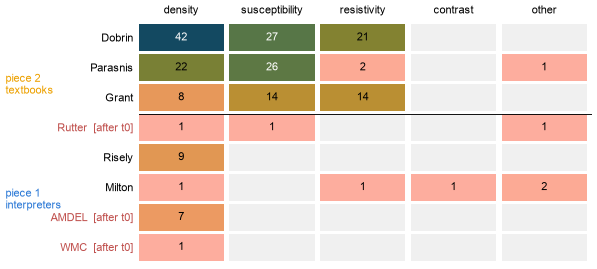

          density  susceptibility  resistivity  contrast  other
Dobrin         42              27           21         0      0
Parasnis       22              26            2         0      1
Grant           8              14           14         0      0
Rutter          1               1            0         0      1
Risely          9               0            0         0      0
Milton          1               0            1         1      2
AMDEL           7               0            0         0      0
WMC             1               0            0         0      0

total rows 202; pre-t0 sources 5 of 8; rows after t0: 11 (Rutter and Esdale 3, AMDEL 7, WMC plans 1)


In [3]:
cls = {"density": "density", "specific gravity": "density", "bulk density": "density",
       "susceptibility": "susceptibility", "resistivity": "resistivity", "conductivity": "resistivity",
       "formation factor": "resistivity", "contrast": "contrast", "depth": "other", "caution": "other",
       "array": "other", "response": "other", "distribution": "susceptibility", "anisotropy": "resistivity"}
def pclass(s):
    for k, v in cls.items():
        if k in s: return v
    return "other"
P["pclass"] = P.property.apply(pclass)
ORDER = ["density", "susceptibility", "resistivity", "contrast", "other"]
SRC = ["Dobrin", "Parasnis", "Grant", "Rutter", "Risely", "Milton", "AMDEL", "WMC"]
M = np.zeros((len(SRC), len(ORDER)), int)
for i, s in enumerate(SRC):
    for j, c in enumerate(ORDER):
        M[i, j] = int(((P.book == s) & (P.pclass == c)).sum())
pre = [bool(P.loc[P.book == s, "pre_t0"].all()) for s in SRC]
fig, ax = plt.subplots(figsize=(COL15, 2.9))
fig.subplots_adjust(left=0.24, right=0.99, top=0.80, bottom=0.04)
vmax = M.max()
for i in range(len(SRC)):
    for j in range(len(ORDER)):
        n = M[i, j]
        ax.add_patch(plt.Rectangle((j, i), 0.94, 0.9, color=BATLOW(0.85 - 0.7 * n / vmax) if n else "#f0f0f0", lw=0))
        if n:
            ax.text(j + 0.47, i + 0.45, str(n), ha="center", va="center", fontsize=FS_ANNOT,
                    color="white" if n > vmax * 0.55 else "black")
ax.set_xlim(0, len(ORDER)); ax.set_ylim(len(SRC), -0.1)
ax.set_xticks(np.arange(len(ORDER)) + 0.47); ax.set_xticklabels(ORDER, fontsize=FS_ANNOT)
ax.xaxis.tick_top(); ax.tick_params(which="both", length=0)
ax.set_yticks(np.arange(len(SRC)) + 0.45)
ax.set_yticklabels([f"{s}{'' if p else '  [after t0]'}" for s, p in zip(SRC, pre)], fontsize=FS_ANNOT)
for t, p in zip(ax.get_yticklabels(), pre):
    t.set_color("black" if p else AFTER_COL)
ax.xaxis.set_minor_locator(plt.NullLocator()); ax.yaxis.set_minor_locator(plt.NullLocator())
for sp in ax.spines.values(): sp.set_visible(False)
ax.axhline(3, color="black", lw=0.6)
fig.text(0.02, 0.60, "piece 2\ntextbooks", fontsize=FS_ANNOT, color=PIECE_COL[2], ha="left", va="center")
fig.text(0.02, 0.24, "piece 1\ninterpreters", fontsize=FS_ANNOT, color=PIECE_COL[1], ha="left", va="center")
fig.savefig(FIG / "wp4_L5_00_sources_by_property.png", dpi=300)
plt.show()
print(pd.DataFrame(M, index=SRC, columns=ORDER).to_string())
print(f"\ntotal rows {M.sum()}; pre-t0 sources {sum(pre)} of {len(SRC)}; "
      f"rows after t0: {int((~P.pre_t0).sum())} (Rutter and Esdale {int((P.book=='Rutter').sum())}, "
      f"AMDEL {int((P.book=='AMDEL').sum())}, WMC plans {int((P.book=='WMC').sum())})")


### How to read this figure

Rows are sources, columns are the four property classes plus a residue; the number in each cell is how many transcribed rows that source contributes, and darker cells hold more rows. Grey cells are empty. The three textbooks above the line are piece 2; the five sources below it are piece 1, and the three labelled in red were written after t0. The pattern to take away is that all 202 rows split very unevenly: density is covered by every source (91 rows), susceptibility only by the books and one sentence of Rutter and Esdale (68 rows), and resistivity only by the books and Milton's 1966 survey (38 rows). No source measured susceptibility or resistivity at Olympic Dam before t0, so those two channels rest on textbooks alone, while density has both era measurements and books behind it.


## Part A, basis piece 1: the contrasts the WMC interpreters assumed

The memoranda and model sheets are not on disk. Part A therefore asks what the surviving record fixes: what contrast was assumed, what the era measurements around it were, and how much the answer moves if the contrast is wrong.


### Step A1. Every contrast on the record

The annex states densities, not a contrast, so the implied contrast is basalt 2.80 to 3.00 less cover 2.4 to 2.6, that is 0.20 to 0.60. Each contrast the folder can cite is drawn against that band.


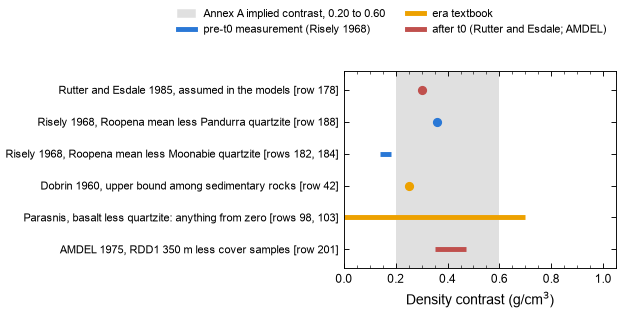

                                              label   lo   hi  kind           ref
       Annex A, basalt 2.80-3.00 less cover 2.4-2.6 0.20 0.60 annex         annex
      Rutter and Esdale 1985, assumed in the models 0.30 0.30 after       row 178
  Risely 1968, Roopena mean less Pandurra quartzite 0.36 0.36   pre       row 188
  Risely 1968, Roopena mean less Moonabie quartzite 0.14 0.18   pre rows 182, 184
   Dobrin 1960, upper bound among sedimentary rocks 0.25 0.25  book        row 42
Parasnis, basalt less quartzite: anything from zero 0.00 0.70  book  rows 98, 103
          AMDEL 1975, RDD1 350 m less cover samples 0.35 0.47 after       row 201

Rutter and Esdale 0.3 sits inside the annex band and between the two Risely contrasts (0.14 and 0.36); the measured contrast at RDD1 350 m is 0.35-0.47


In [4]:
re_c = R(178, "density contrast"); ris_c = R(188, "density contrast"); am_c = R(201, "density contrast")
roo = rng(182); moo = rng(184); pan = rng(185)[0]; wea = rng(181)[0]
roo_mean = 2.8                                        # group means 2.68, 2.82, 2.87 (note on row 182)
CON = pd.DataFrame([
    ("Annex A, basalt 2.80-3.00 less cover 2.4-2.6", 0.20, 0.60, "annex", "annex"),
    ("Rutter and Esdale 1985, assumed in the models", 0.30, 0.30, "after", "row 178"),
    ("Risely 1968, Roopena mean less Pandurra quartzite", roo_mean - pan, roo_mean - pan, "pre", "row 188"),
    ("Risely 1968, Roopena mean less Moonabie quartzite", roo_mean - moo[1], roo_mean - moo[0], "pre", "rows 182, 184"),
    ("Dobrin 1960, upper bound among sedimentary rocks", 0.25, 0.25, "book", "row 42"),
    ("Parasnis, basalt less quartzite: anything from zero", rng(103)[0] - rng(98)[1], rng(103)[1] - rng(98)[0], "book", "rows 98, 103"),
    ("AMDEL 1975, RDD1 350 m less cover samples", 0.35, 0.47, "after", "row 201"),
], columns=["label", "lo", "hi", "kind", "ref"])
KC = {"annex": ANNEX_GREY, "pre": PIECE_COL[1], "book": PIECE_COL[2], "after": AFTER_COL}
fig, ax = plt.subplots(figsize=(COL15, 2.9))
fig.subplots_adjust(left=0.52, right=0.97, top=0.79, bottom=0.17)
ax.axvspan(CON.lo[0], CON.hi[0], color=ANNEX_GREY, lw=0)
for i, r in CON.iloc[1:].iterrows():
    c = KC[r.kind]
    if r.lo == r.hi: ax.plot(r.lo, i, "o", color=c, ms=5)
    else: ax.plot([r.lo, r.hi], [i, i], color=c, lw=3.2, solid_capstyle="butt")
ax.set_xlim(0, 1.05); ax.set_ylim(len(CON) - 0.4, 0.4)
ax.set_yticks(range(1, len(CON))); ax.set_yticklabels([f"{l} [{f}]" for l, f in zip(CON.label[1:], CON.ref[1:])], fontsize=FS_ANNOT)
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.set_xlabel("Density contrast (g/cm$^3$)")
h = [plt.Rectangle((0, 0), 1, 1, color=ANNEX_GREY, label="Annex A implied contrast, 0.20 to 0.60"),
     plt.Line2D([], [], color=PIECE_COL[1], lw=3.2, label="pre-t0 measurement (Risely 1968)"),
     plt.Line2D([], [], color=PIECE_COL[2], lw=3.2, label="era textbook"),
     plt.Line2D([], [], color=AFTER_COL, lw=3.2, label="after t0 (Rutter and Esdale; AMDEL)")]
fig.legend(handles=h, loc="upper center", ncol=2, fontsize=FS_ANNOT, bbox_to_anchor=(0.6, 1.01))
fig.savefig(FIG / "wp4_L5_A1_contrasts.png", dpi=300)
plt.show()
print(CON.round(3).to_string(index=False))
print(f"\nRutter and Esdale 0.3 sits inside the annex band and between the two Risely contrasts "
      f"({roo_mean - moo[1]:.2f} and {roo_mean - pan:.2f}); the measured contrast at RDD1 350 m is 0.35-0.47")


### How to read this figure

Each mark is one density contrast in g/cm3; the grey band is the contrast the annex implies, 0.20 to 0.60. Blue is a pre-t0 measurement, orange an era textbook statement, red a source written after t0. Rutter and Esdale's 0.3, the number WMC put into its block models, sits inside the annex band. The two contrasts computed from Risely's 1968 samples bracket it: 0.36 against the Pandurra quartzite, the unit that actually overlies the basalt at Olympic Dam, and 0.14 against the Moonabie quartzite. The measured contrast at RDD1, 0.35 to 0.47, is higher than assumed, but it belongs to hematite-rich rock rather than to basalt. The widest bar is the point of the figure: Parasnis's own table allows anything from 0.00 to 0.70 for basalt against quartzite, so the books cannot pin the contrast down, which is what Grant and West say in words on their page 199.


### Step A2. What was actually measured, and where

The contrast is a difference between two rock densities, so the next step separates the two sides of it: the pre-t0 surface samples from the Roopena outcrops, and the only densities ever measured in the hole.


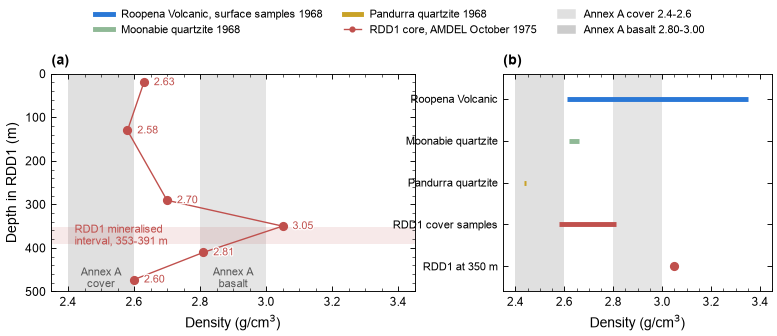

 depth_m  bulk_density  water_absorption_pct
   19.80          2.63                  1.30
  130.45          2.58                  0.76
  290.73          2.70                  0.67
  350.00          3.05                  1.00
  410.30          2.81                  0.37
  472.70          2.60                  0.80

cover samples 2.58-2.81; mineralised sample 3.05; Risely Roopena 2.61-3.35, Pandurra 2.44


In [5]:
dep = np.array([num(R(i).material)[-1] for i in range(195, 201)])
rho = np.array([rng(i)[0] for i in range(195, 201)])
absn = [float(num(R(i).note)[0]) for i in range(195, 201)]
BANDS = [("Roopena Volcanic (Risely 1968)", *rng(182), PIECE_COL[1]),
         ("Moonabie quartzite (Risely 1968)", *rng(184), "#8fb996"),
         ("Pandurra quartzite (Risely 1968)", rng(185)[0] - 0.005, rng(185)[0] + 0.005, "#c9a227"),
         ("Annex A cover, 2.4 to 2.6", 2.4, 2.6, ANNEX_GREY),
         ("Annex A basalt, 2.80 to 3.00", 2.8, 3.0, "0.80")]
fig, axes = plt.subplots(1, 2, figsize=(COL2, 3.0), gridspec_kw={"width_ratios": [1.35, 1]})
fig.subplots_adjust(left=0.08, right=0.99, top=0.80, bottom=0.14, wspace=0.28)
ax = axes[0]
ax.axvspan(2.4, 2.6, color=ANNEX_GREY, lw=0)
ax.axvspan(2.8, 3.0, color="0.80", alpha=0.5, lw=0)
ax.text(2.50, 470, "Annex A\ncover", fontsize=FS_ANNOT, ha="center", va="center", color="0.35")
ax.text(2.90, 470, "Annex A\nbasalt", fontsize=FS_ANNOT, ha="center", va="center", color="0.35")
ax.plot(rho, dep, "o-", color=AFTER_COL, ms=5, lw=0.9)
for d, r in zip(dep, rho):
    ax.text(r + 0.03, d, f"{r:.2f}", fontsize=FS_ANNOT, va="center", color=AFTER_COL, path_effects=HALO)
ax.axhspan(353, 391, color=AFTER_COL, alpha=0.12, lw=0)
ax.text(2.42, 372, "RDD1 mineralised\ninterval, 353-391 m", fontsize=FS_ANNOT, va="center", color=AFTER_COL)
ax.invert_yaxis(); ax.set_xlim(2.35, 3.45); ax.set_ylim(500, 0)
ax.set_xlabel("Density (g/cm$^3$)"); ax.set_ylabel("Depth in RDD1 (m)")
ax = axes[1]
lab = [b[0] for b in BANDS[:3]] + ["RDD1 cover samples", "RDD1 at 350 m"]
lo = [b[1] for b in BANDS[:3]] + [rho[[0, 1, 2, 4, 5]].min(), rho[3]]
hi = [b[2] for b in BANDS[:3]] + [rho[[0, 1, 2, 4, 5]].max(), rho[3]]
col = [PIECE_COL[1], "#8fb996", "#c9a227", AFTER_COL, AFTER_COL]
for i, (l, a, b, c) in enumerate(zip(lab, lo, hi, col)):
    if a == b: ax.plot(a, i, "o", color=c, ms=5)
    else: ax.plot([a, b], [i, i], color=c, lw=3.2, solid_capstyle="butt")
ax.axvspan(2.4, 2.6, color=ANNEX_GREY, lw=0, zorder=0)
ax.axvspan(2.8, 3.0, color="0.80", alpha=0.5, lw=0, zorder=0)
ax.set_yticks(range(len(lab))); ax.set_yticklabels([l.split(" (")[0] for l in lab], fontsize=FS_ANNOT)
ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(len(lab) - 0.4, -0.6)
ax.set_xlim(2.35, 3.45); ax.set_xlabel("Density (g/cm$^3$)")
panel_labels(axes, ("(a)", "(b)"))
h = [plt.Line2D([], [], color=PIECE_COL[1], lw=3.2, label="Roopena Volcanic, surface samples 1968"),
     plt.Line2D([], [], color="#8fb996", lw=3.2, label="Moonabie quartzite 1968"),
     plt.Line2D([], [], color="#c9a227", lw=3.2, label="Pandurra quartzite 1968"),
     plt.Line2D([], [], color=AFTER_COL, marker="o", lw=0.9, label="RDD1 core, AMDEL October 1975"),
     plt.Rectangle((0, 0), 1, 1, color=ANNEX_GREY, label="Annex A cover 2.4-2.6"),
     plt.Rectangle((0, 0), 1, 1, color="0.80", label="Annex A basalt 2.80-3.00")]
fig.legend(handles=h, loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.52, 1.02))
fig.savefig(FIG / "wp4_L5_A2_measured_densities.png", dpi=300)
plt.show()
print(pd.DataFrame({"depth_m": dep, "bulk_density": rho, "water_absorption_pct": absn}).to_string(index=False))
print(f"\ncover samples {rho[[0,1,2,4,5]].min():.2f}-{rho[[0,1,2,4,5]].max():.2f}; mineralised sample {rho[3]:.2f}; "
      f"Risely Roopena {rng(182)[0]:.2f}-{rng(182)[1]:.2f}, Pandurra {rng(185)[0]:.2f}")


### How to read this figure

Panel (a) plots the six AMDEL bulk densities against depth in RDD1, with the mineralised interval 353 to 391 m shaded and the two annex bands in grey. Panel (b) puts the same numbers beside the 1968 surface samples: each bar is a measured range, and the dot is the single 350 m sample. The cover samples in the hole read 2.58 to 2.81, which straddles the top of the annex cover range rather than sitting inside it, and the 350 m sample reads 3.05, above the annex basalt range. On the surface, Risely's Roopena Volcanic samples span 2.61 to 3.35 with group means 2.68 to 2.87, so the basalt side of the contrast was known to the era within about 0.7 g/cm3, while the Pandurra quartzite was a single sample at 2.44. The figure makes the asymmetry plain: the era had many basalt samples and one cover sample, and the rock that turned out to cause the anomaly was denser than either.


### Step A3. How much the depth depends on the contrast

The contrast was not an end in itself; it was an input to a depth. For a body of fixed shape producing the same anomaly, the inferred depth scales as the square root of the assumed contrast, so the era contrast range can be turned into a depth range and compared with the depths WMC published.


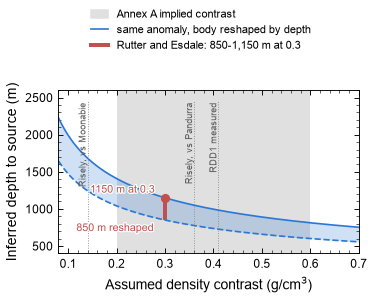

contrast 0.14 (Risely vs Moonabie  ) -> depth 1244 to 1683 m
contrast 0.36 (Risely vs Pandurra  ) -> depth 776 to 1050 m
contrast 0.41 (RDD1 measured       ) -> depth 727 to 984 m

the era contrast range 0.14 to 0.47 moves the inferred depth by a factor of 1.83


In [6]:
z0, z_shape = num(R(180, "depth").value)[0], num(R(180, "depth").value)[1]
d0 = rng(178)[0]
d = np.linspace(0.08, 0.70, 200)
z = z0 * np.sqrt(d0 / d)                                # sphere of fixed radius, same anomaly: z ~ sqrt(drho)
z_lo = z_shape * np.sqrt(d0 / d)
fig, ax = plt.subplots(figsize=(COL1, 2.7))
fig.subplots_adjust(left=0.19, right=0.97, top=0.72, bottom=0.17)
ax.axvspan(0.20, 0.60, color=ANNEX_GREY, lw=0)
ax.fill_between(d, z_lo, z, color=PIECE_COL[1], alpha=0.22, lw=0)
ax.plot(d, z, color=PIECE_COL[1], lw=1.1)
ax.plot(d, z_lo, color=PIECE_COL[1], lw=1.1, ls="--")
ax.plot([d0, d0], [z_shape, z0], color=AFTER_COL, lw=2.6, solid_capstyle="butt", zorder=4)
ax.plot(d0, z0, "o", color=AFTER_COL, ms=5, zorder=5)
ax.text(d0 - 0.02, z0 + 40, f"{z0:.0f} m at {d0}", fontsize=FS_ANNOT, ha="right", va="bottom", color=AFTER_COL, path_effects=HALO)
ax.text(d0 - 0.02, z_shape - 40, f"{z_shape:.0f} m reshaped", fontsize=FS_ANNOT, ha="right", va="top", color=AFTER_COL, path_effects=HALO)
for lab, v in [("Risely, vs Moonabie", 2.8 - rng(184)[1]), ("Risely, vs Pandurra", 2.8 - rng(185)[0]),
               ("RDD1 measured", 0.41)]:
    ax.plot([v, v], [400, 2450], color="0.55", lw=0.6, ls=":")
    ax.text(v, 2430, lab, fontsize=FS_ANNOT - 1, rotation=90, ha="right", va="top", color="0.35")
ax.set_xlim(0.08, 0.70); ax.set_ylim(400, 2600)
ax.set_xlabel("Assumed density contrast (g/cm$^3$)"); ax.set_ylabel("Inferred depth to source (m)")
h = [plt.Rectangle((0, 0), 1, 1, color=ANNEX_GREY, label="Annex A implied contrast"),
     plt.Line2D([], [], color=PIECE_COL[1], lw=1.1, label="same anomaly, body reshaped by depth"),
     plt.Line2D([], [], color=AFTER_COL, lw=2.6, label="Rutter and Esdale: 850-1,150 m at 0.3")]
fig.legend(handles=h, loc="upper center", ncol=1, fontsize=FS_ANNOT, bbox_to_anchor=(0.56, 1.02))
fig.savefig(FIG / "wp4_L5_A3_depth_sensitivity.png", dpi=300)
plt.show()
for v, lab in [(2.8 - rng(184)[1], "Risely vs Moonabie"), (2.8 - rng(185)[0], "Risely vs Pandurra"), (0.41, "RDD1 measured")]:
    print(f"contrast {v:.2f} ({lab:20s}) -> depth {z_shape*np.sqrt(d0/v):.0f} to {z0*np.sqrt(d0/v):.0f} m")
print(f"\nthe era contrast range {2.8-rng(184)[1]:.2f} to 0.47 moves the inferred depth by a factor of "
      f"{np.sqrt(0.47/(2.8-rng(184)[1])):.2f}")


### How to read this figure

The horizontal axis is the assumed density contrast and the vertical axis the depth that would be inferred from the same gravity anomaly, on the sphere scaling z proportional to the square root of the contrast; the solid and dashed curves are anchored on Rutter and Esdale's two published depths at 0.3, 1,150 m and 850 m for a reshaped body, and the shaded wedge between them is that shape freedom carried across the axis. The red bar marks their published pair. Dotted lines mark the era contrasts from Step A1. What the reader should see is how little of the depth uncertainty comes from the contrast: over the era range 0.14 to 0.47 the inferred depth moves by a factor of 1.8, from roughly 730 m to 1,680 m, which is the same order as the shape freedom WMC already allowed themselves. Taking 0.3 as exact was therefore not the binding assumption; the shape was.


### Verdict on piece 1

The number the annex asks for exists, but only in a paper published ten years after t0. Rutter and Esdale's 0.3 g/cm3 is inside the annex band and between the two contrasts a t0 reader could have computed from Risely (1968), so the annex value is defensible on the era record even if the memoranda never surface. What the record does not support is treating it as exact: the era measurements give 0.14 to 0.36 depending on which cover unit is taken, the rock that caused the anomaly measured 0.35 to 0.47 once drilled, and all three textbooks refuse to let a contrast be read off lithology. Level 5 should therefore sample the contrast over about 0.15 to 0.5 rather than fix it at 0.3, and Rutter and Esdale needs the same ruling as Haynes (2006): a later record of a pre-t0 act. Susceptibility and resistivity have no piece 1 evidence at all, only the one word "variable".


## Part B, basis piece 2: the era textbooks

The three books are the backup the annex names. Part B asks whether they support the annex values for each property, and how wide the era uncertainty around them really was.


### Step B1. Density by rock class

The first test is the pair of density ranges the annex fixes: cover 2.4 to 2.6 and basalt 2.80 to 3.00.


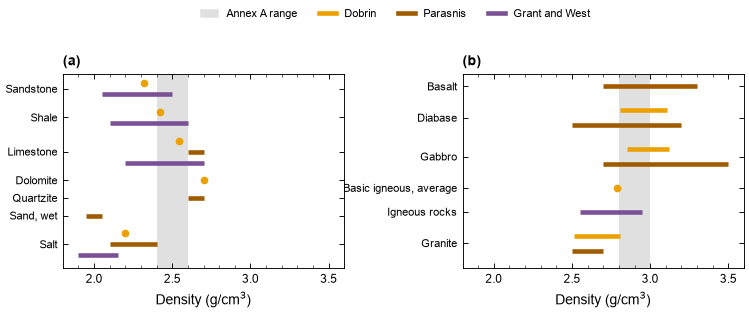

cover entries span 1.90-2.70 g/cm3 against the annex 2.4-2.6
mafic entries span 2.50-3.50 g/cm3 against the annex 2.80-3.00
Parasnis basalt 2.70-3.30; Dobrin diabase 2.804-3.110; Dobrin basic igneous average 2.79


In [7]:
COVER = [("Sandstone", [(35, "Dobrin"), (145, "Grant")]), ("Shale", [(36, "Dobrin"), (144, "Grant")]),
         ("Limestone", [(37, "Dobrin"), (97, "Parasnis"), (143, "Grant")]),
         ("Dolomite", [(39, "Dobrin")]), ("Quartzite", [(98, "Parasnis")]),
         ("Sand, wet", [(92, "Parasnis")]), ("Salt", [(26, "Dobrin"), (95, "Parasnis"), (147, "Grant")])]
MAFIC = [("Basalt", [(103, "Parasnis")]), ("Diabase", [(33, "Dobrin"), (102, "Parasnis")]),
         ("Gabbro", [(32, "Dobrin"), (104, "Parasnis")]), ("Basic igneous, average", [(41, "Dobrin")]),
         ("Igneous rocks", [(142, "Grant")]), ("Granite", [(27, "Dobrin"), (100, "Parasnis")])]
fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.8))
fig.subplots_adjust(left=0.13, right=0.99, top=0.78, bottom=0.15, wspace=0.42)
for ax, items, band, title in [(axes[0], COVER, (2.4, 2.6), "cover units"), (axes[1], MAFIC, (2.8, 3.0), "mafic rocks")]:
    ax.axvspan(*band, color=ANNEX_GREY, lw=0)
    y = 0; ticks, labs = [], []
    for name, refs in items:
        for i, bk in refs:
            lo, hi = rng(i)
            c = BOOK_COL[bk]
            if lo == hi: ax.plot(lo, y, "o", color=c, ms=4)
            else: ax.plot([lo, hi], [y, y], color=c, lw=3, solid_capstyle="butt")
            y += 1
        ticks.append(y - len(refs) / 2 - 0.5); labs.append(name)
        y += 0.6
    ax.set_yticks(ticks); ax.set_yticklabels(labs, fontsize=FS_ANNOT)
    ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(y - 0.4, -0.8)
    ax.set_xlim(1.8, 3.6); ax.set_xlabel("Density (g/cm$^3$)")
panel_labels(axes, ("(a)", "(b)"))
h = [plt.Rectangle((0, 0), 1, 1, color=ANNEX_GREY, label="Annex A range")] + \
    [plt.Line2D([], [], color=c, lw=3, label=k) for k, c in
     [("Dobrin", BOOK_COL["Dobrin"]), ("Parasnis", BOOK_COL["Parasnis"]), ("Grant and West", BOOK_COL["Grant"])]]
fig.legend(handles=h, loc="upper center", ncol=4, fontsize=FS_ANNOT, bbox_to_anchor=(0.55, 1.02))
fig.savefig(FIG / "wp4_L5_B1_density_by_class.png", dpi=300)
plt.show()
cov = [rng(i)[k] for _, refs in COVER for i, _ in refs for k in (0, 1)]
maf = [rng(i)[k] for _, refs in MAFIC[:5] for i, _ in refs for k in (0, 1)]
print(f"cover entries span {min(cov):.2f}-{max(cov):.2f} g/cm3 against the annex 2.4-2.6")
print(f"mafic entries span {min(maf):.2f}-{max(maf):.2f} g/cm3 against the annex 2.80-3.00")
print(f"Parasnis basalt {rng(103)[0]:.2f}-{rng(103)[1]:.2f}; Dobrin diabase {rng(33)[0]:.3f}-{rng(33)[1]:.3f}; "
      f"Dobrin basic igneous average {rng(41)[0]:.2f}")


### How to read this figure

Each bar is one book's entry for one rock class, coloured by book; the grey band in each panel is the annex range, cover on the left and mafic rocks on the right. Panel (a) shows that the annex cover range sits in the middle of the era entries rather than spanning them: Dobrin's laboratory averages run 2.32 for sandstone to 2.70 for dolomite, Grant and West's 80 per cent limits reach from 2.05 for sandstone to 2.70 for limestone, and Parasnis puts limestone and quartzite at 2.60 to 2.70. The annex range is therefore a little low and a little narrow for a quartzite-dominated cover like the Stuart Shelf. Panel (b) supports the basalt range but shows it is narrow too: Parasnis gives basalt 2.70 to 3.30, Dobrin's diabase 2.804 to 3.110 and his basic igneous average 2.79, and Grant and West's igneous limits 2.55 to 2.95. The era view of both sides is wider than the annex allows.


### Step B2. Susceptibility

The annex asks only for a direction here, basalt magnetic and cover non-magnetic, so the test is whether the books agree on that and how far apart their numbers are.


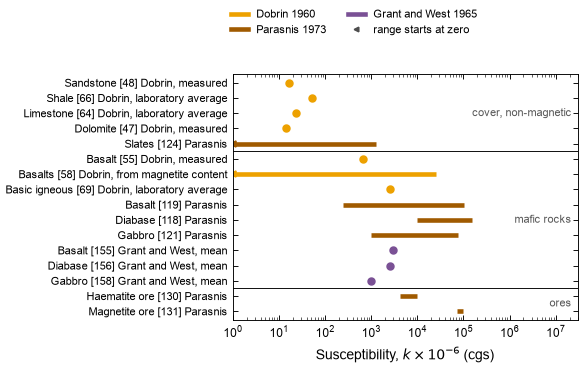

     material  row                         source      lo       hi
    Sandstone   48               Dobrin, measured    16.8     16.8
        Shale   66     Dobrin, laboratory average    52.0     52.0
    Limestone   64     Dobrin, laboratory average    23.0     23.0
     Dolomite   47               Dobrin, measured    14.0     14.0
       Slates  124                       Parasnis     0.0   1250.0
       Basalt   55               Dobrin, measured   680.0    680.0
      Basalts   58 Dobrin, from magnetite content     0.0  26000.0
Basic igneous   69     Dobrin, laboratory average  2596.0   2596.0
       Basalt  119                       Parasnis   250.0 105000.0
      Diabase  118                       Parasnis 10000.0 150000.0
       Gabbro  121                       Parasnis  1000.0  76000.0
       Basalt  155           Grant and West, mean  2950.0   2950.0
      Diabase  156           Grant and West, mean  2590.0   2590.0
       Gabbro  158           Grant and West, mean   990.0    9

In [8]:
SUSROWS = [("Sandstone", 48, "Dobrin, measured"), ("Shale", 66, "Dobrin, laboratory average"),
           ("Limestone", 64, "Dobrin, laboratory average"), ("Dolomite", 47, "Dobrin, measured"),
           ("Slates", 124, "Parasnis"),
           ("Basalt", 55, "Dobrin, measured"), ("Basalts", 58, "Dobrin, from magnetite content"),
           ("Basic igneous", 69, "Dobrin, laboratory average"), ("Basalt", 119, "Parasnis"),
           ("Diabase", 118, "Parasnis"), ("Gabbro", 121, "Parasnis"),
           ("Basalt", 155, "Grant and West, mean"), ("Diabase", 156, "Grant and West, mean"),
           ("Gabbro", 158, "Grant and West, mean"),
           ("Haematite ore", 130, "Parasnis"), ("Magnetite ore", 131, "Parasnis")]
def kvals(i):
    r = R(i)
    v = num(r.value)
    if "emu" in r.unit: v = [x * 1e6 for x in v]                 # emu (cgs volume) to k x 1e-6
    return (min(v[:2]), max(v[:2])) if len(v) > 1 else (v[0], v[0])
fig, ax = plt.subplots(figsize=(COL15, 3.3))
fig.subplots_adjust(left=0.40, right=0.97, top=0.82, bottom=0.14)
rows = SUSROWS
for y, (n, i, s) in enumerate(rows):
    lo, hi = kvals(i)
    c = BOOK_COL[s.split(",")[0].split(" ")[0]] if s.split(",")[0].split(" ")[0] in BOOK_COL else BOOK_COL["Grant"]
    if lo == hi: ax.plot(lo, y, "o", color=c, ms=4.5)
    else: ax.plot([max(lo, 1), hi], [y, y], color=c, lw=3, solid_capstyle="butt")
    if lo == 0: ax.plot(1, y, "<", color=c, ms=4)
ax.set_xscale("log"); ax.set_xlim(1, 3e7)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([f"{n} [{i}] {s}" for n, i, s in rows], fontsize=FS_ANNOT)
ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(len(rows) - 0.4, -0.6)
ax.axhline(4.5, color="black", lw=0.6); ax.axhline(13.5, color="black", lw=0.6)
ax.set_xlabel("Susceptibility, $k \\times 10^{-6}$ (cgs)")
for lab, y in [("cover, non-magnetic", 2), ("mafic rocks", 9), ("ores", 14.5)]:
    ax.text(2.2e7, y, lab, fontsize=FS_ANNOT, ha="right", va="center", color="0.35")
h = [plt.Line2D([], [], color=c, lw=3, label=k) for k, c in
     [("Dobrin 1960", BOOK_COL["Dobrin"]), ("Parasnis 1973", BOOK_COL["Parasnis"]), ("Grant and West 1965", BOOK_COL["Grant"])]]
h += [plt.Line2D([], [], color="0.3", marker="<", ls="", label="range starts at zero")]
fig.legend(handles=h, loc="upper center", ncol=2, fontsize=FS_ANNOT, bbox_to_anchor=(0.6, 1.02))
fig.savefig(FIG / "wp4_L5_B2_susceptibility.png", dpi=300)
plt.show()
print(pd.DataFrame([(n, i, s, *kvals(i)) for n, i, s in SUSROWS], columns=["material", "row", "source", "lo", "hi"]).to_string(index=False))
b_meas, b_calc = kvals(55)[0], kvals(58)[1]
print(f"\nbasalt: Dobrin measured {b_meas:.0f}, Dobrin from magnetite content up to {b_calc:.0f} "
      f"(factor {b_calc/b_meas:.0f}); Grant and West mean {kvals(155)[0]:.0f}; Parasnis {kvals(119)[0]:.0f}-{kvals(119)[1]:.0f}")
print(f"cover rows sit at {kvals(47)[0]:.0f} to {kvals(66)[0]:.0f} (slates reach {kvals(124)[1]:.0f}), "
      f"two to four orders below the mafic rows")
print(f"haematite ore (Parasnis row 130) {kvals(130)[0]:.0f}-{kvals(130)[1]:.0f}, i.e. weakly magnetic, "
      f"far below magnetite ore {kvals(131)[0]:.0f}-{kvals(131)[1]:.0f}")


### How to read this figure

Each bar is one book's susceptibility entry on a logarithmic axis in units of k x 1e-6 cgs; Grant and West's means are converted from emu. The rows are grouped by black lines into cover units, mafic rocks and ores. The direction the annex asks for is clearly supported: the cover entries sit at 14 to 52, with slates reaching 1,250, while the mafic entries sit two to four orders higher. The magnitude is not supported to better than two orders. For basalt alone, Dobrin measured 680, Dobrin's value calculated from magnetite content reaches 26,000, a factor of 38 on the same page, Grant and West's mean is 2,950 and Parasnis spans 250 to 105,000. That spread is the era uncertainty, and it is the reason the annex is right to state a direction rather than a number. The ore rows matter for Part B4: haematite ore is only weakly magnetic at 4,110 to 9,860, far below magnetite ore at 71,000 to 97,000.


### Step B3. Resistivity of the cover

The annex says the cover is conductive where saturated. No one measured resistivity at Olympic Dam before t0, so this rests entirely on the books: their sample tables, and the formation-factor relation that converts porosity and pore-water into rock resistivity.


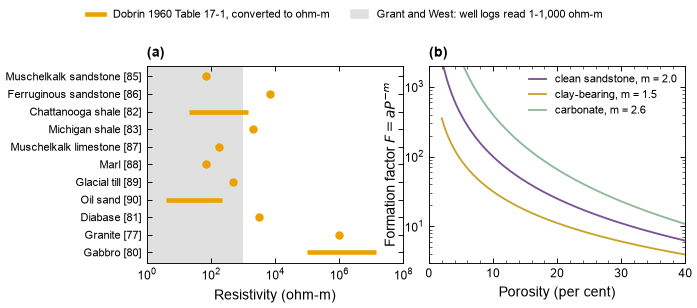

             material  row  lo_ohm_m   hi_ohm_m
Muschelkalk sandstone   85      70.0       70.0
Ferruginous sandstone   86    7000.0     7000.0
    Chattanooga shale   82      20.0     1400.0
       Michigan shale   83    2000.0     2000.0
Muschelkalk limestone   87     180.0      180.0
                 Marl   88      70.0       70.0
         Glacial till   89     500.0      500.0
             Oil sand   90       4.0      220.0
              Diabase   81    3100.0     3100.0
              Granite   77 1000000.0  1000000.0
               Gabbro   80  100000.0 14000000.0

sample resistivities run 4 to 1e+07 ohm-m; in-situ logs read 1-1000 ohm-m (row 165)
at 20 per cent porosity the formation factor is 25 (m = 2.0) and 11 (m = 1.5)


In [9]:
OHMCM = [("Muschelkalk sandstone", 85), ("Ferruginous sandstone", 86), ("Chattanooga shale", 82),
         ("Michigan shale", 83), ("Muschelkalk limestone", 87), ("Marl", 88), ("Glacial till", 89),
         ("Oil sand", 90), ("Diabase", 81), ("Granite", 77), ("Gabbro", 80)]
fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.8))
fig.subplots_adjust(left=0.30, right=0.98, top=0.80, bottom=0.16, wspace=0.10)
ax = axes[0]
lo_g, hi_g = rng(165)
ax.axvspan(lo_g, hi_g, color=ANNEX_GREY, lw=0)
for y, (n, i) in enumerate(OHMCM):
    lo, hi = [v / 100 for v in rng(i)]                     # ohm-cm to ohm-m
    if lo == hi: ax.plot(lo, y, "o", color=BOOK_COL["Dobrin"], ms=4.5)
    else: ax.plot([lo, hi], [y, y], color=BOOK_COL["Dobrin"], lw=3, solid_capstyle="butt")
ax.set_xscale("log"); ax.set_xlim(1, 1e8)
ax.set_yticks(range(len(OHMCM))); ax.set_yticklabels([f"{n} [{i}]" for n, i in OHMCM], fontsize=FS_ANNOT)
ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(len(OHMCM) - 0.4, -0.6)
ax.set_xlabel("Resistivity (ohm-m)")
ax = axes[1]
por = np.linspace(0.02, 0.40, 200)
for m, a, lab, c in [(2.0, 1.0, "clean sandstone, m = 2.0", BOOK_COL["Grant"]),
                     (1.5, 1.0, "clay-bearing, m = 1.5", "#c9a227"),
                     (2.6, 1.0, "carbonate, m = 2.6", "#8fb996")]:
    ax.plot(por * 100, a * por ** (-m), color=c, lw=1.2, label=lab)
ax.set_xscale("linear"); ax.set_yscale("log"); ax.set_xlim(0, 40); ax.set_ylim(3, 2000)
ax.set_xlabel("Porosity (per cent)"); ax.set_ylabel("Formation factor $F = aP^{-m}$")
ax.legend(fontsize=FS_ANNOT, loc="upper right")
panel_labels(axes, ("(a)", "(b)"))
h = [plt.Line2D([], [], color=BOOK_COL["Dobrin"], lw=3, label="Dobrin 1960 Table 17-1, converted to ohm-m"),
     plt.Rectangle((0, 0), 1, 1, color=ANNEX_GREY, label="Grant and West: well logs read 1-1,000 ohm-m")]
fig.legend(handles=h, loc="upper center", ncol=2, fontsize=FS_ANNOT, bbox_to_anchor=(0.55, 1.01))
fig.savefig(FIG / "wp4_L5_B3_resistivity.png", dpi=300)
plt.show()
print(pd.DataFrame([(n, i, *[v / 100 for v in rng(i)]) for n, i in OHMCM],
                   columns=["material", "row", "lo_ohm_m", "hi_ohm_m"]).to_string(index=False))
print(f"\nsample resistivities run {min(rng(i)[0]/100 for _, i in OHMCM):.0f} to "
      f"{max(rng(i)[1]/100 for _, i in OHMCM):.0e} ohm-m; in-situ logs read {lo_g:.0f}-{hi_g:.0f} ohm-m (row 165)")
print(f"at 20 per cent porosity the formation factor is {0.2**-2.0:.0f} (m = 2.0) and {0.2**-1.5:.0f} (m = 1.5)")


### How to read this figure

Panel (a) shows Dobrin's Table 17-1 entries converted from ohm-cm to ohm-m on a logarithmic axis, with the band marking Grant and West's statement that in-situ well logs read 1 to 1,000 ohm-m. The contrast between the two is the point: dried laboratory samples of the same sedimentary rocks read from 4 to 7,000 ohm-m, and igneous samples up to 1e7, while rock in place with saline pore water reads three to six orders lower. Panel (b) is the mechanism Grant and West give for that, the formation factor F = aP^-m: at 20 per cent porosity the rock is 25 times its pore-water resistivity for clean sandstone (m = 2.0) and 11 times for clay-bearing rock (m = 1.5). So "conductive where saturated" is supported as a statement about pore water and porosity, not as a rock property, and the annex should attach resistivity through porosity and water rather than by rock name.


### Step B4. Whether the ore blanket could be seen

The last annex claim is that the ore blanket is close to invisible to gravity and magnetics. That can be tested directly from era mineral densities and one era yardstick on disk: the residual gravity contrast Milton measured over the Mount Gunson ore in 1966.


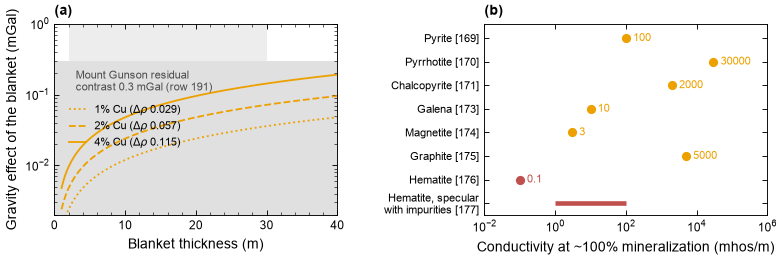

1% Cu as chalcopyrite ->  1.8 vol%, drho 0.029 g/cm3, slab effect 0.002 mGal at 2 m and 0.036 mGal at 30 m
2% Cu as chalcopyrite ->  3.6 vol%, drho 0.057 g/cm3, slab effect 0.005 mGal at 2 m and 0.072 mGal at 30 m
4% Cu as chalcopyrite ->  7.2 vol%, drho 0.115 g/cm3, slab effect 0.010 mGal at 2 m and 0.144 mGal at 30 m

the era yardstick on disk is Mount Gunson's 0.3 mGal residual contrast (row 191), where seven methods showed no diagnostic relationship to the ore (row 193)
hematite conducts 0.1 mhos/m, 1-100 in specular form with impurities, against chalcopyrite 2e3 mhos/m


In [10]:
rho_ccp, rho_host = rng(106)[0], 2.60                  # chalcopyrite (row 106); host from the cover rows
CU_IN_CCP = 0.346
t = np.linspace(1, 40, 200)
fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.8))
fig.subplots_adjust(left=0.09, right=0.99, top=0.78, bottom=0.16, wspace=0.52)
ax = axes[0]
milton = rng(191)[0]
ax.axhspan(0.001, milton, color=ANNEX_GREY, lw=0)
for g, ls in [(1.0, ":"), (2.0, "--"), (4.0, "-")]:
    wf = g / 100 / CU_IN_CCP
    vf = wf * rho_host / rho_ccp
    drho = vf * (rho_ccp - rho_host)
    ax.plot(t, SLAB * drho * t, color=PIECE_COL[2], ls=ls, lw=1.2, label=f"{g:.0f}% Cu ($\\Delta\\rho$ {drho:.3f})")
ax.axvspan(2, 30, color="0.93", lw=0, zorder=0)
ax.set_yscale("log"); ax.set_xlim(0, 40); ax.set_ylim(2e-3, 1)
ax.set_xlabel("Blanket thickness (m)"); ax.set_ylabel("Gravity effect of the blanket (mGal)")
ax.legend(fontsize=FS_ANNOT, loc="upper left", bbox_to_anchor=(0.02, 0.62))
ax.text(3, milton * 0.75, f"Mount Gunson residual\ncontrast {milton} mGal (row 191)", fontsize=FS_ANNOT, va="top", color="0.3")
ax = axes[1]
CND = [("Pyrite", 169), ("Pyrrhotite", 170), ("Chalcopyrite", 171), ("Galena", 173),
       ("Magnetite", 174), ("Graphite", 175), ("Hematite", 176)]
for y, (n, i) in enumerate(CND):
    v = re.search(r"~100% mineralization ([0-9.e+]+)", R(i).value)
    val = float(v.group(1))
    c = AFTER_COL if n == "Hematite" else PIECE_COL[2]
    ax.plot(val, y, "o", color=c, ms=5)
    ax.text(val * 1.6, y, f"{val:g}", fontsize=FS_ANNOT, va="center", color=c)
lo_h, hi_h = rng(177)
ax.plot([lo_h, hi_h], [len(CND), len(CND)], color=AFTER_COL, lw=3, solid_capstyle="butt")
ax.set_xscale("log"); ax.set_xlim(1e-2, 1e6)
ax.set_yticks(range(len(CND) + 1))
ax.set_yticklabels([f"{n} [{i}]" for n, i in CND] + ["Hematite, specular\nwith impurities [177]"], fontsize=FS_ANNOT)
ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(len(CND) + 0.5, -0.6)
ax.set_xlabel("Conductivity at ~100% mineralization (mhos/m)")
panel_labels(axes, ("(a)", "(b)"))
fig.savefig(FIG / "wp4_L5_B4_ore_visibility.png", dpi=300)
plt.show()
for g in (1.0, 2.0, 4.0):
    wf = g / 100 / CU_IN_CCP; vf = wf * rho_host / rho_ccp; drho = vf * (rho_ccp - rho_host)
    print(f"{g:.0f}% Cu as chalcopyrite -> {vf*100:4.1f} vol%, drho {drho:.3f} g/cm3, "
          f"slab effect {SLAB*drho*2:.3f} mGal at 2 m and {SLAB*drho*30:.3f} mGal at 30 m")
print(f"\nthe era yardstick on disk is Mount Gunson's {milton} mGal residual contrast (row 191), "
      f"where seven methods showed no diagnostic relationship to the ore (row 193)")
print(f"hematite conducts {re.search(r'~100% mineralization ([0-9.e+]+)', R(176).value).group(1)} mhos/m, "
      f"{lo_h:.0f}-{hi_h:.0f} in specular form with impurities, against chalcopyrite "
      f"{re.search(r'~100% mineralization ([0-9.e+]+)', R(171).value).group(1)} mhos/m")


### How to read this figure

Panel (a) gives the gravity effect of an infinite slab of ore, 0.04193 mGal per g/cm3 per metre, against its thickness, for three grades. The grade is converted to a volume fraction of chalcopyrite using Parasnis's density of 4.2 for that mineral and a host of 2.60, so 4 per cent copper is 7.2 per cent chalcopyrite by volume and raises the bulk density by only 0.115 g/cm3. The lighter vertical band is the annex blanket thickness, 2 to 30 m, and the grey horizontal band is everything below Milton's 0.3 mGal residual contrast at Mount Gunson. Even the thickest, richest blanket gives 0.14 mGal, half that yardstick, and a 2 m blanket gives 0.01 mGal. Panel (b) is the electrical side: each dot is an ore mineral's conductivity at full mineralization from Grant and West's Table 13-1. Hematite, in red, reads 0.1 mhos/m, rising to only 1 to 100 in specular form with impurities, against 2,000 for chalcopyrite and 30,000 for pyrrhotite. The annex claim is therefore supported twice over, and in the era's own terms: the blanket is too light to see with gravity, and hematite ore is neither magnetic enough nor conductive enough to see by the other channels.


### Verdict on piece 2

The three books do the job the annex assigns them, with one qualification each. Density: both annex ranges are supported but both are narrower than the era spread, and the cover range is a little low for a quartzite cover. Susceptibility: the direction is supported emphatically, the magnitude only to within two orders, so basalt susceptibility must be sampled over a wide range rather than set. Resistivity: supported only as a statement about saturation and porosity, through the formation factor, with no era measurement at the deposit to anchor it. Ore visibility: supported directly, by the slab calculation from era mineral densities and by hematite's conductivity, and independently by Milton's 1966 finding at the analog. Shear velocity: nothing exists in any of the three books for the period, which is what the annex already says.


## Part C. The Annex A Level 5 rows against the level folder

The last step puts each annex value beside the range the folder can cite, with the rows behind it, and writes the table to `03_results/wp4_prior/wp4_L5_parameter_rows.csv`.


                                    parameter                                 annex_value                                                                                                                                                                                                                             in_state_value                                 source                                                           status
                               basalt density                          2.80 to 3.00 g/cm3                                                                                                       Parasnis 2.70-3.30; Dobrin diabase 2.80-3.11, basic igneous average 2.79; Grant and West igneous 2.55-2.95; Risely Roopena 2.61-3.35             rows 33, 41, 103, 142, 182                                              in state, supported
                                cover density                            2.4 to 2.6 g/cm3                                                     

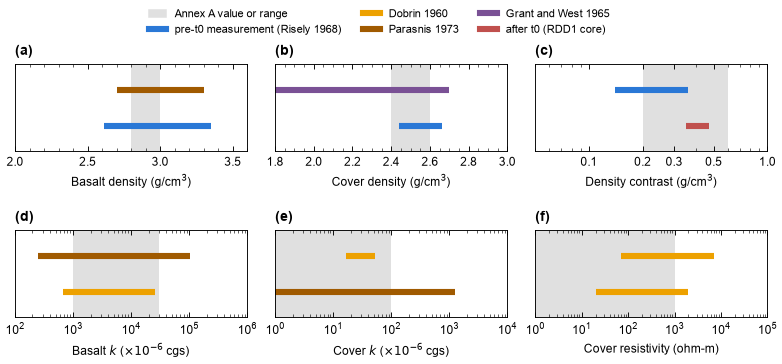

In [11]:
rows = pd.DataFrame([
    ("basalt density", "2.80 to 3.00 g/cm3", f"Parasnis {rng(103)[0]:.2f}-{rng(103)[1]:.2f}; Dobrin diabase "
     f"{rng(33)[0]:.2f}-{rng(33)[1]:.2f}, basic igneous average {rng(41)[0]:.2f}; Grant and West igneous "
     f"{rng(142)[0]:.2f}-{rng(142)[1]:.2f}; Risely Roopena {rng(182)[0]:.2f}-{rng(182)[1]:.2f}",
     "rows 33, 41, 103, 142, 182", "in state, supported"),
    ("cover density", "2.4 to 2.6 g/cm3", f"Dobrin averages {rng(35)[0]:.2f}-{rng(39)[0]:.2f}; Grant and West limits "
     f"{rng(145)[0]:.2f}-{rng(143)[1]:.2f}; Risely Pandurra {rng(185)[0]:.2f}, Moonabie {rng(184)[0]:.2f}-{rng(184)[1]:.2f}; "
     f"RDD1 cover core 2.58-2.81", "rows 35-39, 143-146, 184, 185, 195-200", "in state, supported"),
    ("density contrast for the anomaly", "0.3 g/cm3 (WMC)", f"Rutter and Esdale 0.3 (after t0); Risely 1968 gives "
     f"{2.8-rng(184)[1]:.2f} to {2.8-rng(185)[0]:.2f}; RDD1 measured 0.35-0.47; all three books say a contrast cannot be "
     f"pinned from lithology", "rows 42, 148, 178, 188, 201", "carry as a distribution, not a number"),
    ("basalt susceptibility", "magnetic", f"Dobrin measured {kvals(55)[0]:.0f}, from magnetite content up to {kvals(58)[1]:.0f}; "
     f"Parasnis {kvals(119)[0]:.0f}-{kvals(119)[1]:.0f}; Grant and West mean {kvals(155)[0]:.0f} (x 1e-6 cgs)",
     "rows 55, 58, 119, 155", "in state; two orders of spread, no WMC number"),
    ("cover susceptibility", "non-magnetic", f"{kvals(48)[0]:.0f} to {kvals(66)[0]:.0f} x 1e-6 cgs (sandstone, shale, "
     f"limestone, dolomite, slates); Grant and West: 73 per cent of sedimentary samples below 1e-4 emu",
     "rows 47, 48, 63-66, 124, 154", "in state, supported"),
    ("cover resistivity, conductive where saturated", "conductive where saturated", f"sample values "
     f"{rng(85)[0]/100:.0f}-{rng(86)[1]/100:.0f} ohm-m for sandstone and {rng(82)[0]/100:.0f}-{rng(83)[1]/100:.0f} for shale; "
     f"in-situ logs {rng(165)[0]:.0f}-{rng(165)[1]:.0f} ohm-m; formation factor F = aP^-m with m 1.5-2.6",
     "rows 82-90, 165-168", "in state, from the books only; no era measurement at the deposit"),
    ("ore blanket close to invisible", "close to invisible to gravity and magnetics", "a 30 m blanket at 4% Cu as "
     "chalcopyrite gives 0.15 mGal, below Mount Gunson's 0.3 mGal residual contrast, where seven methods showed no "
     "diagnostic relationship; haematite ore is weakly magnetic and hematite is not normally a conductor",
     "rows 106, 130, 176, 177, 191, 193", "in state, supported"),
    ("shear velocity", "undefined (no era value)", "nothing in the three books or the era reports on disk; the annex "
     "already states the seismic channel is undefined under the period prior", "none", "correct as written"),
], columns=["parameter", "annex_value", "in_state_value", "source", "status"])
rows.to_csv(TAB / "wp4_L5_parameter_rows.csv", index=False)
print(rows.to_string(index=False))

PAN = [("Basalt density (g/cm$^3$)", (2.8, 3.0), [(rng(103)[0], rng(103)[1], BOOK_COL["Parasnis"]),
        (rng(182)[0], rng(182)[1], PIECE_COL[1])], (2.0, 3.6), "linear"),
       ("Cover density (g/cm$^3$)", (2.4, 2.6), [(rng(146)[0], rng(143)[1], BOOK_COL["Grant"]),
        (rng(185)[0], rng(184)[1], PIECE_COL[1])], (1.8, 3.0), "linear"),
       ("Density contrast (g/cm$^3$)", (0.2, 0.6), [(2.8 - rng(184)[1], 2.8 - rng(185)[0], PIECE_COL[1]),
        (0.35, 0.47, AFTER_COL)], (0.05, 1.0), "log"),
       ("Basalt $k$ ($\\times 10^{-6}$ cgs)", (1e3, 3e4), [(kvals(119)[0], kvals(119)[1], BOOK_COL["Parasnis"]),
        (kvals(55)[0], kvals(58)[1], BOOK_COL["Dobrin"])], (1e2, 1e6), "log"),
       ("Cover $k$ ($\\times 10^{-6}$ cgs)", (1, 100), [(kvals(48)[0], kvals(66)[0], BOOK_COL["Dobrin"]),
        (kvals(124)[0] + 1, kvals(124)[1], BOOK_COL["Parasnis"])], (1, 1e4), "log"),
       ("Cover resistivity (ohm-m)", (1, 1000), [(rng(85)[0] / 100, rng(86)[1] / 100, BOOK_COL["Dobrin"]),
        (rng(82)[0] / 100, rng(83)[1] / 100, BOOK_COL["Dobrin"])], (1, 1e5), "log")]
fig, axes = plt.subplots(2, 3, figsize=(COL2, 3.2))
fig.subplots_adjust(left=0.04, right=0.99, top=0.84, bottom=0.12, wspace=0.12, hspace=0.9)
for ax, (lab, band, bars, xl, sc) in zip(axes.flat, PAN):
    ax.axvspan(*band, color=ANNEX_GREY, lw=0)
    for j, (lo, hi, c) in enumerate(bars):
        ax.plot([lo, hi], [j, j], color=c, lw=4, solid_capstyle="butt")
    ax.set_xscale(sc); ax.set_xlim(*xl); ax.set_ylim(1.7, -0.7)
    ax.set_yticks([]); ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_xlabel(lab, fontsize=FS_ANNOT + 1)
    if "contrast" in lab.lower():
        ax.set_xticks([0.1, 0.2, 0.3, 0.5, 1.0]); ax.set_xticklabels(["0.1", "0.2", "0.3", "0.5", "1.0"])
        ax.xaxis.set_minor_formatter(plt.NullFormatter())
panel_labels(axes.flat, ("(a)", "(b)", "(c)", "(d)", "(e)", "(f)"))
h = [plt.Rectangle((0, 0), 1, 1, color=ANNEX_GREY, label="Annex A value or range"),
     plt.Line2D([], [], color=PIECE_COL[1], lw=4, label="pre-t0 measurement (Risely 1968)"),
     plt.Line2D([], [], color=BOOK_COL["Dobrin"], lw=4, label="Dobrin 1960"),
     plt.Line2D([], [], color=BOOK_COL["Parasnis"], lw=4, label="Parasnis 1973"),
     plt.Line2D([], [], color=BOOK_COL["Grant"], lw=4, label="Grant and West 1965"),
     plt.Line2D([], [], color=AFTER_COL, lw=4, label="after t0 (RDD1 core)")]
fig.legend(handles=h, loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.5, 1.02))
fig.savefig(FIG / "wp4_L5_C1_parameters.png", dpi=300)
plt.show()


### How to read this figure

Each panel is one annex value on a logarithmic axis, with the grey band the annex range and the bars the era evidence, coloured by source. (a) Basalt density: Parasnis and Risely's samples both reach well above the annex 2.80 to 3.00. (b) Cover density: the era entries straddle the annex 2.4 to 2.6, with Risely's two cover units on either side of it. (c) Contrast: the pre-t0 range 0.14 to 0.36 and the measured 0.35 to 0.47 overlap the annex band but are not centred on 0.3. (d) Basalt susceptibility: two orders of era spread against a band drawn here at 1,000 to 30,000 for comparison. (e) Cover susceptibility: the era values cluster at 14 to 52, below the comparison band, which is the "non-magnetic" the annex asks for. (f) Cover resistivity: the sample values sit above the in-situ 1 to 1,000 ohm-m band, the difference being saturation. Read together, the panels say that Level 5's directions are right and its widths are too narrow.


## What this shows

Level 5 comes out better supported than Level 4 but needs its uncertainties widened. The annex's directions all hold on the era record: basalt denser and magnetic, cover lighter and non-magnetic, cover conductive where saturated, ore close to invisible. Three of its numbers should be rewritten as distributions rather than values. The density contrast should be sampled over about 0.15 to 0.5 g/cm3 instead of fixed at 0.3, because that is the range the era measurements give depending on which cover unit is taken, and because every one of the three books says a contrast cannot be read from lithology. Basalt susceptibility should span at least 250 to 105,000 x 1e-6 cgs, since the era sources disagree by two orders and one book disagrees with itself by a factor of 38. Cover resistivity should be attached through porosity and pore-water with the formation factor, not by rock name, since no era measurement at the deposit exists.

Two findings are worth carrying into WP4's later tasks. First, the depth sensitivity in Step A3: the contrast is not the binding assumption in the era interpretation, the body's shape is, so a prior that samples shape generously and contrast narrowly would misplace the uncertainty. Second, the ore blanket really is invisible in era terms, which means the discovery cannot be attributed to the ore's own signature: what WMC chased was the basalt and the hematite-rich breccia around the ore, not the copper.

Open for the advisor: (1) the standing of Rutter and Esdale 1985, a 1985 record of a pre-t0 act, which is the same question as Haynes 2006; (2) whether to request WMC's sample and model sheets from BHP; (3) the 2.20 g/cm3 reduction density printed on the December 1975 gravity plans beside an elevation correction factor that implies 2.40, which needs a look at the original sheet; (4) whether the RDD1 sample logged at 472.70 m, below RDD1's final depth of 411.10 m, is in fact an RDD2 sample, as the table's own labelling suggests.
